# COCO Project 2026 - Submission

This file is your workspace, it is what you submit to the engineers of the technical team. There are some slight restrictions as your controller will be automatically tested after submission.

Otherwise, you can be as creative as you want! For example implementing your own function to run a simulation.

## Structure
The first code block defines some imports, feel free to adjust it. You should only use the packages available (see `pyproject.toml`). If you think a package is missing, add a post in the project forum on Moodle or write an e-mail to [Benjamin](mailto:bestadle@student.ethz.ch). 

### Figures
All figures you create for the slides have to be automatically generated by running this notebook and saved to `submission_folder/slidedeck_figures/` as png formats. See relevant documentation [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html) or [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html#matplotlib.figure.Figure.savefig).

### Evaluation
For the automation we run your notebook top to bottom. We then use the controller `submission_controller` which you have to define in the last code block. Please ensure that your code completes within a reasonable time, if not, comment on the runtime and use precomputed results.

For the documentation for the engineers, use the provided markdown cell.

### Escaping Notebooks
You may write your code outside of this notebook!
Add all additional code _within_ the `submission_folder` folder and simply submit the submission folder. Note that this notebook must still be present and serving as the code entry point.

**→ Tip when using files**
```python
%load_ext autoreload
%autoreload 2
```
Enable the auto reload flags by adding above block to a cell and executing it. This automatically reloads the source once you changed it. Otherwise, you have to restart the jupyter kernel on every code change.

# Documentation for Engineers

## Failure Scenario

To define a scenario, user_args is available. Please note that if one of these parameters is not explicitly declared in the simulation, it will go back to its standard value. `"initial_position"`, `"initial_state"` and `"random_initial_position"` are mutually exclusive.

user_args = {

    "initial_position": (0.5, 0.9, 0.0),
    "initial_state": (0.5, 0.9, 0.0, 0.0, 0.0, 0.0),
    "random_initial_position": False,  
    "enable_wind": False,
    "initial_barge_position": (0.5, 0.00),
    "enable_moving_barge": False,
    "mass_correction_factor": 1.0,  
    "main_thruster_range": 1.0,
    "side_thruster_range": 1.0,
    "nozzle_angle_range": 1.0

}

The parameters above represent the standard case. Possible scenarios that were considered likely were investigated, and both the PID controller and the recommended controller were benchmarked. For the sake of statistical relevance, 50 rollouts were conducted for each scenario by randomizing the initial position:  x ~ U(0.2,0.8), y ~ U(0.7, 0.9), theta ~ U(-0.1, 0.1).
 
scenario = {

    "initial_position": (float(np.random.uniform(0.2, 0.8)),
                        float(np.random.uniform(0.7, 0.9)),
                        float(np.random.uniform(-0.1, 0.1)))
            
}

In the listed scenarios, the PID had approximately 24% success rate, while the recommended controller 100%.  

**Failure scenario 1: Reduced thrusters efficiency**

This scenario examines a coordinated 20% reduction in both main and side thruster performance limits.

user_args = {
    
    "main_thruster_range": 0.8,
    "side_thruster_range": 0.8, 
    **scenario
    
    }

**Failure scenario 2: Mass variations ±20%**

This setup introduces uncertainty on the rocket's total mass, by randomly sampling the mass correction factor according to mass_correction_factor ~ U(0.8,1.2).

scenario["mass_correction_factor"] = float(np.random.uniform(0.8, 1.2))

user_args = {

    **scenario
    
}

**Failure scenario 3: Nozzle angle range reduction**

This test isolates a 20% degradation of the nozzle angle range.

user_args = {

    "nozzle_angle_range": 0.8,
    **scenario

}


## Controller

Please note that tuned parameters have already been provided after extended testing on the simulator.

**MPC Parameters**


dt: sampling time. Lower values will grant smoother control and more reactiveness, but the optimization problem will become larger (N must be increased to optimize over the same temporal window), thus increasing the computational cost. Default: dt=0.05.

N: Time Horizon. Longer time horizons will the controller a longer foresight, thus handling better the constraints and getting closer to stability. However, this will increase computational cost, and that performance might worsen in case on model mismatch. Default: N=30.

Q_mpc: State weighting matrix. It penalizes the error between the current state and the desired one. Changing parameters will affect behaviour (i.e. increasing cost for vertical velocity will make the rocket descend slower). Default: np.diag([10.0, 5.0, 15.0, 80.0, 600.0, 600.0]).

R_mpc: Input weighting matrix. It penalizes the input variable v. Higher values will smoothen the control actions, but the error correction will be slower. Default: np.diag([2.5, 2.5, 5.0]).

**Nested LQR Parameters**

Q_lqr: penalizes the error in the LQR. It is tuned to prioritize orientation theta=0. Default: np.diag([1.0, 1.0, 1.0, 1.0, 1000.0, 1000.0]).

R_lqr: penalizes control input in the LQR. It is tuned to swing freely to correct orientation. Default: np.diag([2.5, 2.5, 0.05]).

P_lqr: Terminal state weighting matrix. It is chosen over a terminal state, or a terminal region to avoid unfeasibility issues. It is given by the Discrete Algebraic Riccati Equation, as it gives the best possible cost-to-go beyond the horizon. 

L_lqr: Optimal Feedback Gain for LQR. It is obtained from P_lqr.


**Luenberger Observer Parameters**

Q_obs: process noise covariance matrix. Represents the uncertainty of the model. Default: scipy.linalg.block_diag(np.eye(6), 1000.0 * np.eye(3)).

R_obs: measurement noise covariance matrix. Represents the uncertainty of the measurement: the measurements are certain, so it is low. Default: 0.01 * np.eye(6).

P_obs: comes from solving the DARE, needed to compute L_obs.

L_obs: Observer Gain Matrix. It multiplies the innovation to estimate the disturbance.


**Steady-State Target Selector**

R_s: penalizes the difference between u_s and u_hover. Default: np.diag([5.0, 5.0, 5.0]).



In [32]:
# imports
import numpy as np
import matplotlib.pyplot as plt

import coco_rocket_lander
from coco_rocket_lander.algs import Controller
from coco_rocket_lander.env import SystemModel, UserArgs
from coco_rocket_lander.utils import show_video, simulate_controller

In [33]:
# your code
import cvxpy as cp
import scipy.linalg

class MPC (Controller):
    """
    MPC + Disturbance estimation through Luenberger observator + Nested LQR 
    to stabilize the rocket around theta=0.
    """
    def __init__(self,env):
        '''
        Initialization of the class (Model, MPC parameters, Nested LQR parameters, CVXPY problem).
        '''
        # Take linear model and discretize it
        self.model=SystemModel(env.unwrapped)
        self.model.calculate_linear_system_matrices()

        self.dt=0.05
        self.model.discretize_system_matrices(self.dt)
        self.A,self.B=self.model.get_discrete_linear_system_matrices()

        # Physical parameters
        self.mass, _ = env.unwrapped.get_mass_properties()
        self.gravity = env.unwrapped.cfg.gravity

        # u_eq = [mg, 0, 0] (unnormalized)
        u_hover = -self.gravity * self.mass / env.unwrapped.cfg.main_engine_thrust
        self.u_eq=np.array([u_hover,0.0,0.0])

        # MPC Parameters
        self.N=30
        self.state_ref=np.zeros(6)
        self.Q_mpc = np.diag([10.0, 5.0, 15.0, 80.0, 600.0, 600.0])
        self.R_mpc = np.diag([2.5, 2.5, 5.0])
        # Nested LQR parameters
        Q_lqr = np.diag([1.0, 1.0, 1.0, 1.0, 1000.0, 1000.0])
        R_lqr = np.diag([2.5, 2.5, 0.05])
        self.P_lqr = scipy.linalg.solve_discrete_are(self.A, self.B, Q_lqr, R_lqr)
        self.L_lqr = -scipy.linalg.inv(R_lqr + self.B.T @ self.P_lqr @ self.B) @ (self.B.T @ self.P_lqr @ self.A)

        # Luenberger observer 
        self.B_d = self.B.copy()   

        A_aug = np.block([[self.A, self.B_d],
                        [np.zeros((3, 6)), np.eye(3)]])
        C_aug = np.hstack([np.eye(6), np.zeros((6, 3))])

        Q_obs = scipy.linalg.block_diag(np.eye(6), 1000.0 * np.eye(3) )
        R_obs = 0.01 * np.eye(6)    

        
        P_obs = scipy.linalg.solve_discrete_are(A_aug.T, C_aug.T, Q_obs, R_obs)
        L_obs = (scipy.linalg.inv(R_obs + C_aug @ P_obs @ C_aug.T) @ C_aug @ P_obs @ A_aug.T).T   

        self.L_x = L_obs[:6, :]    
        self.L_d = L_obs[6:, :]

        # Observer
        self.x_hat   = np.zeros(6)
        self.d_hat   = np.zeros(3)
        self.prev_u = self.u_eq.copy()
        self.step   = 0
        
        # Define x_init and x_target as Parameters as they will change at each step
        self.x_init = cp.Parameter(6)
        self.x_target = cp.Parameter(6) # It changes with enable_moving_barge=True
        self.u_eq_par = cp.Parameter(3)
     
        # Define cp Variables
        self.x = cp.Variable((6, self.N + 1))
        self.v = cp.Variable((3, self.N))     

        # Initialize cost to 0
        cost = 0
        # Initialize the state
        constraints = [self.x[:, 0] == self.x_init]

        for k in range(self.N):
            # Defining the control action
            u=self.v[:, k] + self.L_lqr @ (self.x[:, k] - self.x_target)
            u_actual=u + self.u_eq_par
            # Quadratic cost for tracking
            cost += cp.quad_form(self.x[:, k] - self.x_target, self.Q_mpc) + cp.quad_form(u, self.R_mpc)
            # Constraints on the state
            constraints += [self.x[:, k + 1] == self.A @ self.x[:, k] + self.B @ (u_actual)]     # Dynamics
            constraints += [self.x[0, k+1] <= 33.333, self.x[0, k+1] >= 0.0,                     # Constraints on X                  
                            self.x[1, k+1] <= 26.666, self.x[1, k+1] >= 0.0,                     # Constraints on Y
                            self.x[4, k+1] <= 0.6108 ,self.x[4, k+1] >= -0.6108]                 # Constraints on theta
            # Constraints on the inputs
            constraints += [u_actual[0] <= 1.0, u_actual[0] >= 0.0,                              # Constraints on F_E
                            u_actual[1] <= 1.0, u_actual[1] >= -1.0,                             # Constraints on F_S
                            u_actual[2] <= 1.0, u_actual[2] >= -1.0]                             # Constraints on phi
        # Terminal cost
        cost += cp.quad_form(self.x[:, self.N] - self.x_target, self.P_lqr)          
        # By using a terminal cost there is not the problem of the region of attraction       

        # Define the cp Problem
        self.problem = cp.Problem(cp.Minimize(cost), constraints)

    def update_observer(self, x_meas):
        '''
        Updates the disturbance estimation by using the Luenberger observer.
        '''
        self.step += 1
        # Initialization: there is no history to estimate from, leave d_hat=0
        if self.step == 1:
            self.x_hat = x_meas.copy()
            return

        # Evaluates accuracy of the model
        x_pred = (self.A @ self.x_hat + self.B @ self.prev_u + self.B_d @ self.d_hat)
        innov = x_meas - x_pred

        if self.step == 2:
            # When the first residual is available, d_hat is initialized
            # through the pseudoinverse of B_pinv for faster convergence
            B_pinv = np.linalg.pinv(self.B_d)
            self.d_hat = np.clip(B_pinv @ innov, -0.9, 0.9)
            self.x_hat = x_meas.copy()
            return

        # Standard Luenberger observer 
        self.x_hat = x_pred + self.L_x @ innov
        self.d_hat = np.clip(self.d_hat + self.L_d @ innov,-0.9, 0.9) # Clip to avoid divergence

    def compute_us(self, x_target):
        """
        Computes the steady-state input that compensates the estimated
        disturbance, so that the MPC always plans around the true reachable
        equilibrium rather than the nominal one. As x_target is not affected by 
        disturbances, it can be used as x_s.
        """
        # Define steady-state input as variable
        u_s = cp.Variable(3)
        
        b_target = (np.eye(6) - self.A) @ x_target - self.B_d @ self.d_hat
        Rs = np.diag([5.0, 5.0, 5.0])
        # To avoid unfeasibility, the code does not impose the equality
        # but highly penalizes violations
        cost = (10000.0 * cp.sum_squares(self.B @ u_s - b_target)
                + cp.quad_form(u_s - self.u_eq, Rs))

        # Constraints on input
        constraints = [u_s[0] <= 1.0, u_s[0] >= 0.0,
                       u_s[1] <= 1.0, u_s[1] >= -1.0,
                       u_s[2] <= 1.0, u_s[2] >= -1.0]

        # Define the cp Problem
        prob = cp.Problem(cp.Minimize(cost), constraints)
        try:
            prob.solve(solver=cp.MOSEK)
            if prob.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                return u_s.value
        except Exception:
            # Fallback: correct the main thrust using vertical d_hat
            u_s = self.u_eq.copy()
            if abs(self.B[3, 0]) > 1e-6:
                u_s[0] = np.clip(self.u_eq[0] - self.d_hat[1] / self.B[3, 0], 0.0, 1.0)
            return u_s

        

    def compute_action(self, state, env):
        '''
        Computes the control action at each timestep by using the controller.
        '''
        # If there is contact with both legs, turn off the engine
        if state[6] == 1.0 and state[7] == 1.0:
            return np.array([0.0, 0.0, 0.0], dtype=np.float64)
        
        # Update the disturbance
        x_meas=state[:6]
        self.update_observer(x_meas)

        # Set the target
        target = env.unwrapped.get_landing_position()
        self.x_target.value = np.array([target[0], target[1], 0.0, 0.0, target[2], 0.0])
        # Compute steady-state input
        u_s=self.compute_us(self.x_target.value)
        
        # Update the cp Problem parameters
        self.x_init.value = x_meas
        self.u_eq_par.value = u_s
        x_error = x_meas - self.x_target.value

        # Solve using MOSEK
        try:
            self.problem.solve(solver=cp.MOSEK,warm_start=True)
            if self.problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                raise ValueError(f"CVXPY Status: {self.problem.status}")
            action = self.v[:, 0].value  + self.L_lqr @ x_error + u_s
            
        except Exception as e:
            # Fallback : LQR to stabilize the orientation
            action = self.L_lqr @ x_error + u_s

        # Clip action 
        action[0] = np.clip(action[0], 0.0, 1.0)
        action[1] = np.clip(action[1], -1.0, 1.0)
        action[2] = np.clip(action[2], -1.0, 1.0)

        # Saves the action for disturbance estimation
        self.prev_u = action.copy()

        
        return action

In [34]:
import gymnasium as gym
from coco_rocket_lander.utils import simulate_controller, show_video
from coco_rocket_lander.algs import PID_controller

try:
    env.close()
except:
    pass

engine_pid_params = [10, 0, 10]
engine_vector_pid_params = [0.085, 0.001, 10.55]
side_engine_pid_params = [5, 0, 6]

pid_controller = PID_controller(engine_pid_params, engine_vector_pid_params, side_engine_pid_params)

env = gym.make("coco_rocket_lander/RocketLander-v0", 
    render_mode="rgb_array", 
    args={})

submission_controller: Controller = MPC(env)
"""
Controller as submitted to the company. Add your final controller here!
This is the controller that will be automatically tested.

To test whether you did it correctly, you can check whether the following line of code works:
simulate_controller(submission_controller)
"""

'\nController as submitted to the company. Add your final controller here!\nThis is the controller that will be automatically tested.\n\nTo test whether you did it correctly, you can check whether the following line of code works:\nsimulate_controller(submission_controller)\n'

In [ ]:
"""
This script is used to run the controller. 
"""
import gymnasium as gym
from coco_rocket_lander.utils import simulate_controller, show_video

try:
    env.close()
except:
    pass


env = gym.make("coco_rocket_lander/RocketLander-v0", 
    render_mode="rgb_array", 
    args={})

submission_controller: Controller = MPC(env)

simulate_controller(controller=submission_controller,
    user_args={"initial_position": (0.45, 0.6, 0.4),
    "random_initial_position": False,  
    "enable_wind": True,
    "enable_moving_barge": True,
    "mass_correction_factor": 1.2,  
    "main_thruster_range": 0.7,
    "side_thruster_range": 0.9,
    "nozzle_angle_range": 0.8},
    video_name="mpc_test",)

env.close()

try:
    show_video(r'mpc_test')
except Exception as e:
    print(f"Error in show_video, check the folder. Detail: {e}")


In [ ]:
# Utils

import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Font Setup 
plt.rcParams.update({'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'], 
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 12})

output_dir = "slidedeck_figures"
os.makedirs(output_dir, exist_ok=True)

def simulate_trajectory(controller, user_args=None):
    """
    Simulate the environment and get the trajectory. 
    Extract coordinates and evaluates rewards (success).
    """
    args_to_use = user_args.copy() if user_args else {}
    
    env = gym.make("coco_rocket_lander/RocketLander-v0", render_mode="rgb_array", args=args_to_use)
    obs, info = env.reset(seed=0)
    target = env.unwrapped.get_landing_position()
    
    x_history, y_history = [obs[0]], [obs[1]]
    last_reward = 0

    step_counter = 0
    max_steps = 2500
    done = False
    
    while not done and step_counter<max_steps:
        action = controller.compute_action(state=obs, env=env.unwrapped)
        obs, reward, terminated, truncated, info = env.step(action)
        
        x_history.append(obs[0])
        y_history.append(obs[1])
        last_reward = reward

        done = terminated or truncated
        step_counter +=1
            
    env.close()
    success = (last_reward == 100)
    return x_history, y_history, target, success

def run_batch_tests_and_plot(controller, title_prefix, base_args, scenarios, filename):
    """
    Run Batch tests for a controller and save plot.
    """
    successes = 0
    num_iterations = len(scenarios)
    target_pos = None

    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    print(f"=== {title_prefix.upper()} ===")
    for i, scenario_args in enumerate(scenarios):
        current_args = {**base_args, **scenario_args}
        
        x_hist, y_hist, target, success = simulate_trajectory(controller, user_args=current_args)
        
        if success:
            successes += 1
            
        print(f"Test {i+1:02d}/{num_iterations} | Pos: {scenario_args.get('initial_position')}")
        
        if target_pos is None:
            target_pos = target
            
        ax.plot(x_hist, y_hist, linestyle='-', alpha=0.8)

    # Draw the barge
    if target_pos is not None:
        ax.scatter([target_pos[0]], [target_pos[1]], color='green', marker='X', s=150, zorder=5)

    # Plotting settings
    ax.set_title(f'{title_prefix} (Successes: {successes}/{num_iterations})')
    ax.set_xlabel('X Position [m]')
    ax.set_ylabel('Y Position [m]')
    ax.set_xlim([0.0, 100/3])
    ax.set_ylim([5.0, 80/3])
    ax.grid(True, linestyle=':', alpha=0.7)

    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Successes: {successes}/{num_iterations}\n")

def generate_random_scenarios(num_iterations=20, randomize_mass=False, mass_range=(0.8, 1.2)):
    """Generates num_iterations of scenarios by choosing parameters in a uniform distribution"""
    np.random.seed(42)
    scenarios = []
    for _ in range(num_iterations):
        scenario = {"initial_position": (float(np.random.uniform(0.2, 0.8)),
                float(np.random.uniform(0.7, 0.9)),
                float(np.random.uniform(-0.1, 0.1)))}
        if randomize_mass:
            scenario["mass_correction_factor"] = float(np.random.uniform(*mass_range))
        scenarios.append(scenario)
    return scenarios

standard_scenarios = generate_random_scenarios(50, randomize_mass=False)
mass_scenarios = generate_random_scenarios(50, randomize_mass=True, mass_range=(0.8, 1.2))
stress_scenarios = generate_random_scenarios(50, randomize_mass=True, mass_range=(0.5, 1.5))

def plot_pid_actuators(controller, output_dir):
    """Simulates PID and plots actuator inputs for the standard test case."""
    env = gym.make("coco_rocket_lander/RocketLander-v0", args={"initial_position": (0.46, 0.9, 0.0)})
    obs, _ = env.reset(seed=42)
    history, t = [], 0.0
    
    while True:
        act = controller.compute_action(state=obs, env=env.unwrapped)
        history.append([t, *act])
        obs, _, done, _, _ = env.step(act)
        t += 0.05
        if done: break
    env.close()

    hist = np.array(history)
    
    plt.rcParams['mathtext.default'] = 'regular'

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    
    cfg = [(r'Main Thruster ($F_E$)', (0.0, 1.0), 'royalblue'),
        (r'Side Thruster ($F_S$)', (-1.0, 1.0), 'darkorange'),
        (r"Nozzle Angle ($\phi$)", (-1.0, 1.0), 'forestgreen')]
    
    for i, ax in enumerate(axs):
        lbl, lim, col = cfg[i]
        ax.plot(hist[:, 0], hist[:, i+1], color=col, lw=2, label='PID Inputs')
        ax.axhline(y=lim[0], color='crimson', ls='--', alpha=0.7, label='Constraints' if i==0 else "")
        ax.axhline(y=lim[1], color='crimson', ls='--', alpha=0.7)
        ax.set_title(lbl)
        ax.set_ylabel('Value')
        ax.set_xlabel('Time [s]')
        ax.grid(True, ls=':', alpha=0.5)
        ax.set_ylim(lim[0] - 0.2, lim[1] + 0.2)
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'slide1b.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

Simulating: PID (Standard)...
Simulating: PID (With Wind)...
Simulating: PID (Slightly offset )...
Simulating: PID (Offset - Mass 110%)...
Simulating: PID (Offset - Thrusters 90%)...
Simulating: PID (Offset - Nozzle range 90%)...


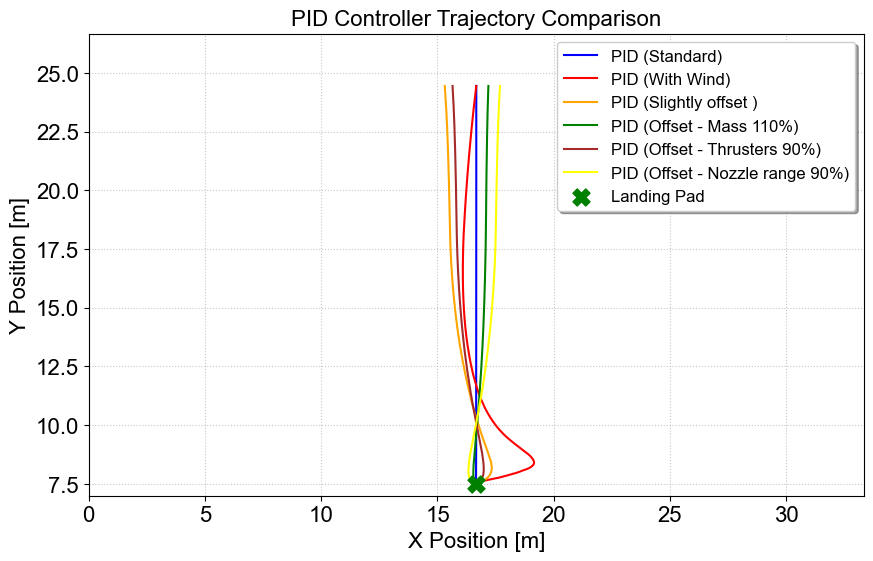

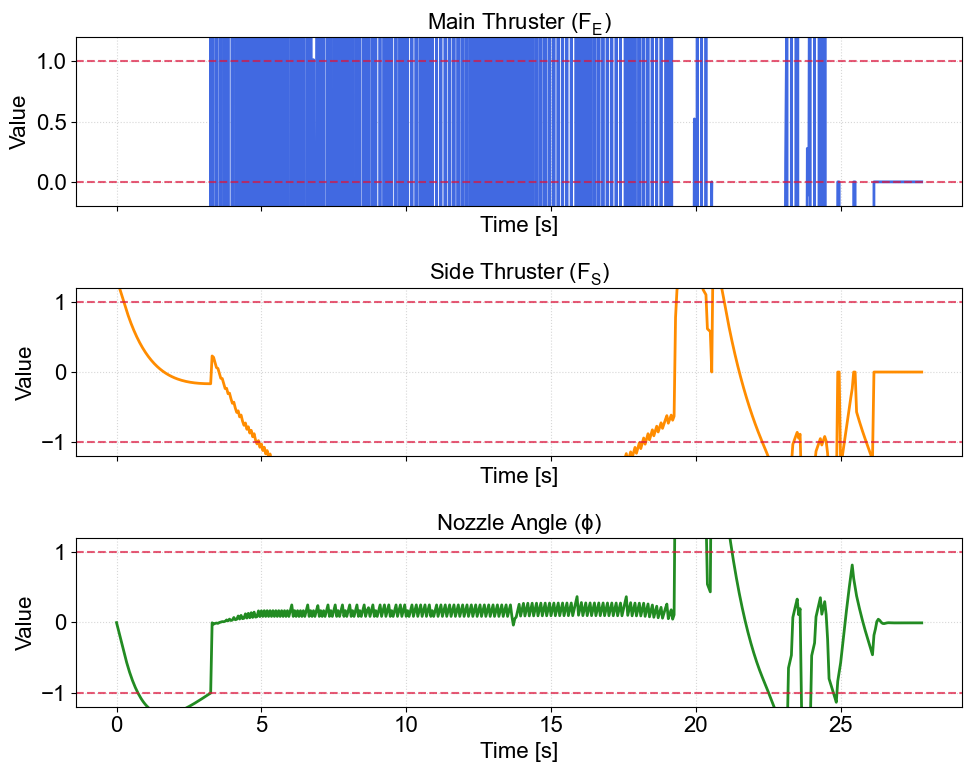

In [27]:
# Slide 1

test_configs_slide1 = {
    'PID (Standard)': {'args': {"initial_position": (0.5, 0.9, 0.0)}, 'c': 'blue'},
    'PID (With Wind)': {'args': {"enable_wind": True, "initial_position": (0.5, 0.9, 0.0)}, 'c': 'red'},
    'PID (Slightly offset )': {'args': {"initial_position": (0.46, 0.9, 0.05)}, 'c': 'orange'},
    'PID (Offset - Mass 110%)': {'args': {"initial_position": (0.515, 0.9, -0.05), "mass_correction_factor": 1.1}, 'c': 'green'},
    'PID (Offset - Thrusters 90%)': {'args': {"initial_position": (0.47, 0.9, 0.05), "main_thruster_range":0.9, "side_thruster_range":0.9}, 'c': 'brown'},
    'PID (Offset - Nozzle range 90%)': {'args': {"initial_position": (0.53, 0.9, -0.05), "nozzle_angle_range":0.9}, 'c': 'yellow'}
}

plt.figure(figsize=(10, 6))
target_pos_s1 = None

for label, config in test_configs_slide1.items():
    print(f"Simulating: {label}...")
    x_h, y_h, target, _ = simulate_trajectory(pid_controller, user_args=config['args'])
    if target_pos_s1 is None: target_pos_s1 = target
    plt.plot(x_h, y_h, label=label, color=config['c'], linestyle='-')

if target_pos_s1 is not None:
    plt.scatter([target_pos_s1[0]], [target_pos_s1[1]], color='green', marker='X', s=150, label='Landing Pad', zorder=5)

plt.title('PID Controller Trajectory Comparison')
plt.xlabel('X Position [m]'); plt.ylabel('Y Position [m]')
plt.xlim([0.0, 100/3]); plt.ylim([7.0, 80/3])
plt.legend(bbox_to_anchor=(1, 1), loc='upper right', shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)

plt.savefig(os.path.join(output_dir, 'slide1a.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

plot_pid_actuators(pid_controller, output_dir)



=== PID - THRUSTERS EFFICIENCY REDUCED BY 20% ===
Test 01/50 | Pos: (0.42472407130841755, 0.8901428612819833, 0.04639878836228101)
Test 02/50 | Pos: (0.559195090518222, 0.7312037280884873, -0.06880109593275947)
Test 03/50 | Pos: (0.23485016730091968, 0.8732352291549871, 0.020223002348641758)
Test 04/50 | Pos: (0.6248435466776274, 0.7041168988591604, 0.09398197043239886)
Test 05/50 | Pos: (0.6994655844802531, 0.7424678221356552, -0.06363500655857987)
Test 06/50 | Pos: (0.3100427059120603, 0.7608484485919075, 0.004951286326447563)
Test 07/50 | Pos: (0.4591670111852695, 0.7582458280396084, 0.02237057894447589)
Test 08/50 | Pos: (0.2836963163912251, 0.7584289297070436, -0.02672763134126166)
Test 09/50 | Pos: (0.4736419905302216, 0.8570351922786027, -0.060065243568328056)
Test 10/50 | Pos: (0.508540663048167, 0.8184829137724084, -0.09070991745600046)
Test 11/50 | Pos: (0.5645269111408631, 0.7341048247374583, -0.08698968140294411)
Test 12/50 | Pos: (0.769331322352, 0.8931264066149118, 0.0616

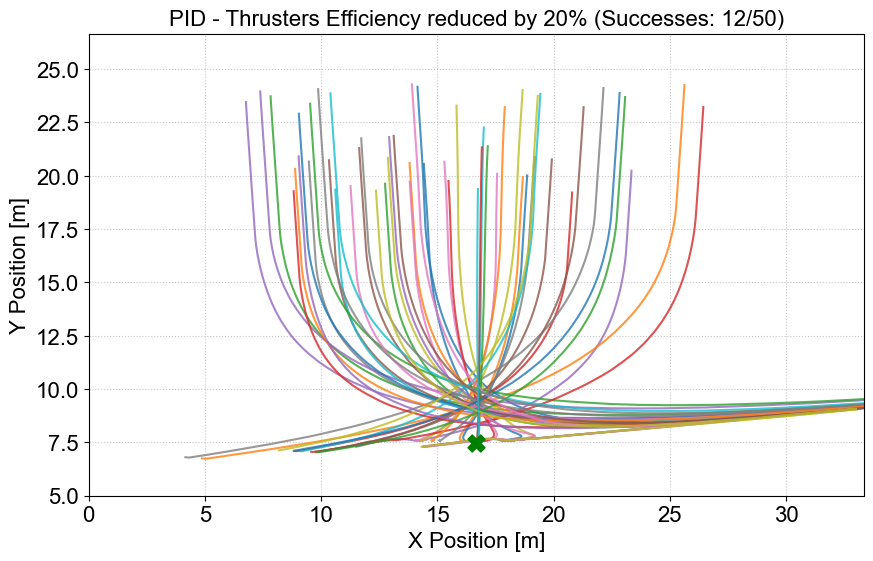

Successes: 12/50

=== MPC - THRUSTERS EFFICIENCY REDUCED BY 20% ===
Test 01/50 | Pos: (0.42472407130841755, 0.8901428612819833, 0.04639878836228101)
Test 02/50 | Pos: (0.559195090518222, 0.7312037280884873, -0.06880109593275947)
Test 03/50 | Pos: (0.23485016730091968, 0.8732352291549871, 0.020223002348641758)
Test 04/50 | Pos: (0.6248435466776274, 0.7041168988591604, 0.09398197043239886)
Test 05/50 | Pos: (0.6994655844802531, 0.7424678221356552, -0.06363500655857987)
Test 06/50 | Pos: (0.3100427059120603, 0.7608484485919075, 0.004951286326447563)
Test 07/50 | Pos: (0.4591670111852695, 0.7582458280396084, 0.02237057894447589)
Test 08/50 | Pos: (0.2836963163912251, 0.7584289297070436, -0.02672763134126166)
Test 09/50 | Pos: (0.4736419905302216, 0.8570351922786027, -0.060065243568328056)
Test 10/50 | Pos: (0.508540663048167, 0.8184829137724084, -0.09070991745600046)
Test 11/50 | Pos: (0.5645269111408631, 0.7341048247374583, -0.08698968140294411)
Test 12/50 | Pos: (0.769331322352, 0.893126

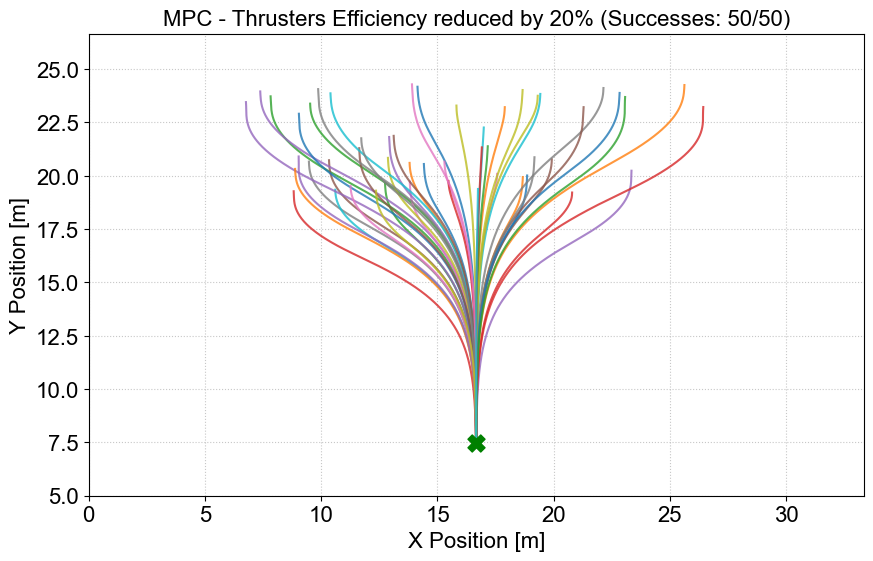

Successes: 50/50



In [ ]:
# Slide 2 & Slide 4 - Failure 1 (Thrusters)

thruster_args = {"main_thruster_range": 0.8, "side_thruster_range": 0.8}

run_batch_tests_and_plot(pid_controller, 'PID - Thrusters Efficiency reduced by 20%', thruster_args, standard_scenarios, 'slide2_thruster.png')

run_batch_tests_and_plot(submission_controller, 'MPC - Thrusters Efficiency reduced by 20%', thruster_args, standard_scenarios, 'slide4_thruster.png')


=== PID - MASS RANDOMIZED UNIFORMLY BETWEEN ±20% ===
Test 01/50 | Pos: (0.42472407130841755, 0.8901428612819833, 0.04639878836228101)
Test 02/50 | Pos: (0.29361118426546196, 0.7311989040672405, -0.08838327756636011)
Test 03/50 | Pos: (0.5606690070459254, 0.8416145155592091, -0.09588310114083952)
Test 04/50 | Pos: (0.6994655844802531, 0.7424678221356552, -0.06363500655857987)
Test 05/50 | Pos: (0.38254534577572263, 0.8049512863264475, -0.013610996271576845)
Test 06/50 | Pos: (0.5671117368334277, 0.7278987721304083, -0.04157107029295637)
Test 07/50 | Pos: (0.4736419905302216, 0.8570351922786027, -0.060065243568328056)
Test 08/50 | Pos: (0.5554487413172255, 0.7092900825439995, 0.02150897038028768)
Test 09/50 | Pos: (0.23903095579116773, 0.8897771074506666, 0.09312640661491187)
Test 10/50 | Pos: (0.38276826150402243, 0.7195344228012768, 0.03684660530243139)
Test 11/50 | Pos: (0.27322294090686733, 0.799035382022254, -0.09312229577695633)
Test 12/50 | Pos: (0.3552679889600102, 0.832504456870

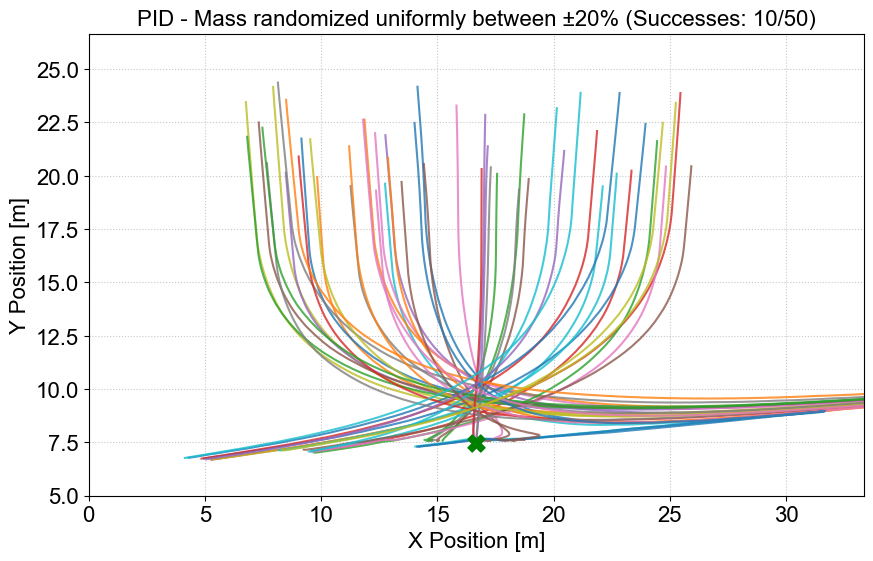

Successes: 10/50

=== MPC - MASS RANDOMIZED UNIFORMLY BETWEEN ±20% ===
Test 01/50 | Pos: (0.42472407130841755, 0.8901428612819833, 0.04639878836228101)
Test 02/50 | Pos: (0.29361118426546196, 0.7311989040672405, -0.08838327756636011)
Test 03/50 | Pos: (0.5606690070459254, 0.8416145155592091, -0.09588310114083952)
Test 04/50 | Pos: (0.6994655844802531, 0.7424678221356552, -0.06363500655857987)
Test 05/50 | Pos: (0.38254534577572263, 0.8049512863264475, -0.013610996271576845)
Test 06/50 | Pos: (0.5671117368334277, 0.7278987721304083, -0.04157107029295637)
Test 07/50 | Pos: (0.4736419905302216, 0.8570351922786027, -0.060065243568328056)
Test 08/50 | Pos: (0.5554487413172255, 0.7092900825439995, 0.02150897038028768)
Test 09/50 | Pos: (0.23903095579116773, 0.8897771074506666, 0.09312640661491187)
Test 10/50 | Pos: (0.38276826150402243, 0.7195344228012768, 0.03684660530243139)
Test 11/50 | Pos: (0.27322294090686733, 0.799035382022254, -0.09312229577695633)
Test 12/50 | Pos: (0.35526798896001

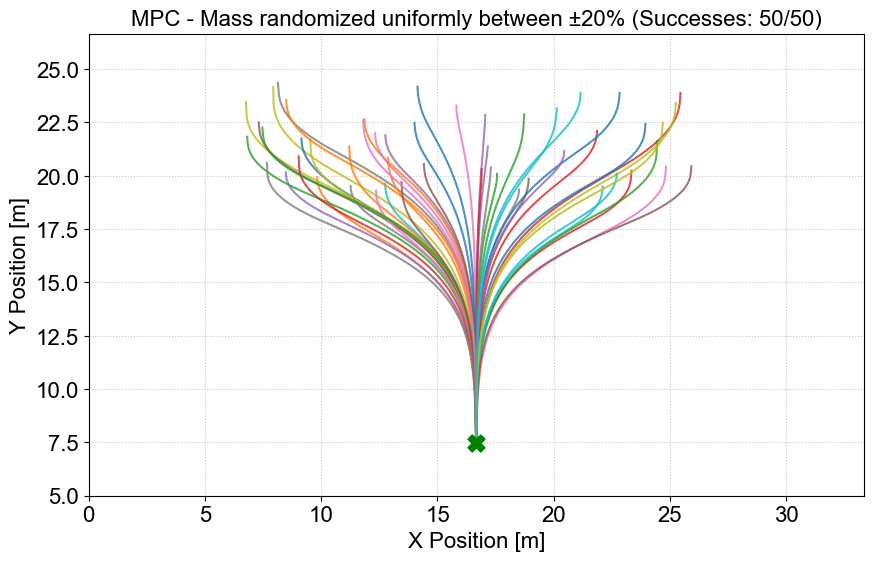

Successes: 50/50



In [ ]:
# Slide 2 & Slide 4 - Failure 2 (Mass)

mass_base_args = {"main_thruster_range": 1.0, "side_thruster_range": 1.0}

run_batch_tests_and_plot(pid_controller, 'PID - Mass randomized uniformly between ±20%', mass_base_args, mass_scenarios, 'slide2_mass.png')

run_batch_tests_and_plot(submission_controller, 'MPC - Mass randomized uniformly between ±20%', mass_base_args, mass_scenarios, 'slide4_mass.png')


=== PID - NOZZLE ANGLE RANGE REDUCED BY 20% ===
Test 01/50 | Pos: (0.42472407130841755, 0.8901428612819833, 0.04639878836228101)
Test 02/50 | Pos: (0.559195090518222, 0.7312037280884873, -0.06880109593275947)
Test 03/50 | Pos: (0.23485016730091968, 0.8732352291549871, 0.020223002348641758)
Test 04/50 | Pos: (0.6248435466776274, 0.7041168988591604, 0.09398197043239886)
Test 05/50 | Pos: (0.6994655844802531, 0.7424678221356552, -0.06363500655857987)
Test 06/50 | Pos: (0.3100427059120603, 0.7608484485919075, 0.004951286326447563)
Test 07/50 | Pos: (0.4591670111852695, 0.7582458280396084, 0.02237057894447589)
Test 08/50 | Pos: (0.2836963163912251, 0.7584289297070436, -0.02672763134126166)
Test 09/50 | Pos: (0.4736419905302216, 0.8570351922786027, -0.060065243568328056)
Test 10/50 | Pos: (0.508540663048167, 0.8184829137724084, -0.09070991745600046)
Test 11/50 | Pos: (0.5645269111408631, 0.7341048247374583, -0.08698968140294411)
Test 12/50 | Pos: (0.769331322352, 0.8931264066149118, 0.061679

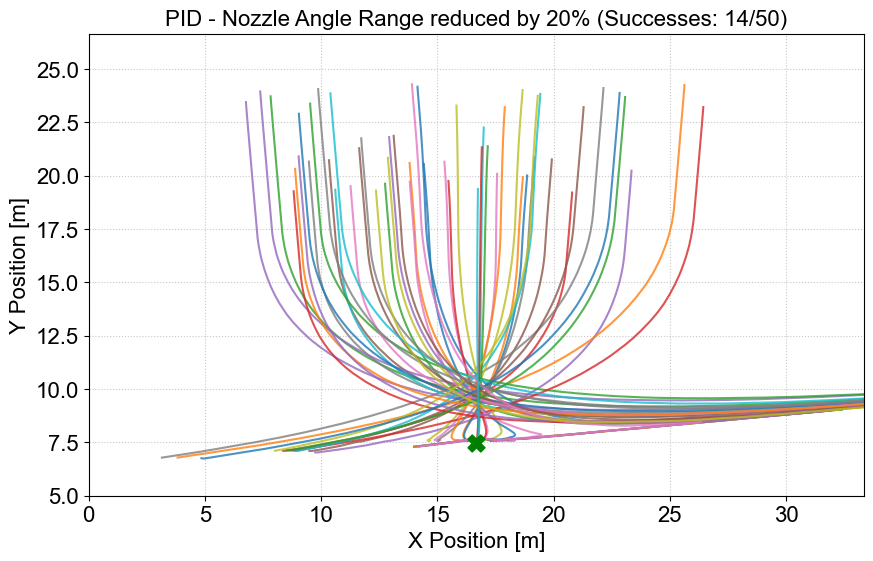

Successes: 14/50

=== MPC - NOZZLE ANGLE RANGE REDUCED BY 20% ===
Test 01/50 | Pos: (0.42472407130841755, 0.8901428612819833, 0.04639878836228101)
Test 02/50 | Pos: (0.559195090518222, 0.7312037280884873, -0.06880109593275947)
Test 03/50 | Pos: (0.23485016730091968, 0.8732352291549871, 0.020223002348641758)
Test 04/50 | Pos: (0.6248435466776274, 0.7041168988591604, 0.09398197043239886)
Test 05/50 | Pos: (0.6994655844802531, 0.7424678221356552, -0.06363500655857987)
Test 06/50 | Pos: (0.3100427059120603, 0.7608484485919075, 0.004951286326447563)
Test 07/50 | Pos: (0.4591670111852695, 0.7582458280396084, 0.02237057894447589)
Test 08/50 | Pos: (0.2836963163912251, 0.7584289297070436, -0.02672763134126166)
Test 09/50 | Pos: (0.4736419905302216, 0.8570351922786027, -0.060065243568328056)
Test 10/50 | Pos: (0.508540663048167, 0.8184829137724084, -0.09070991745600046)
Test 11/50 | Pos: (0.5645269111408631, 0.7341048247374583, -0.08698968140294411)
Test 12/50 | Pos: (0.769331322352, 0.89312640

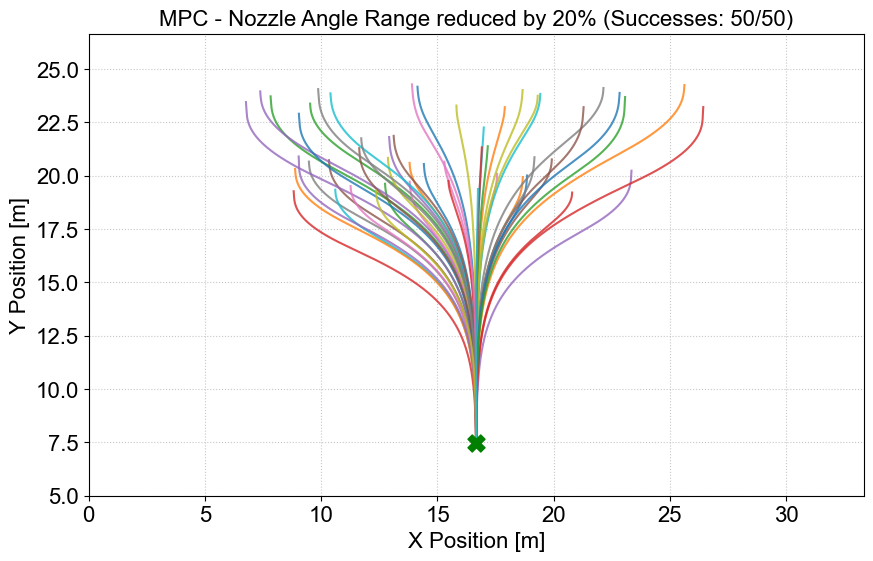

Successes: 50/50



In [ ]:
# Slide 2 & Slide 4 - Failure 3 (Nozzle Angle Range)

nozzle_args = {"nozzle_angle_range": 0.8}

run_batch_tests_and_plot(pid_controller, 'PID - Nozzle Angle Range reduced by 20%', nozzle_args, standard_scenarios, 'slide2_nozzle.png')

run_batch_tests_and_plot(submission_controller, 'MPC - Nozzle Angle Range reduced by 20%', nozzle_args, standard_scenarios, 'slide4_nozzle.png')



=== MPC STRESS TEST TRAJECTORIES ===
Test 01/50 | Pos: (0.42472407130841755, 0.8901428612819833, 0.04639878836228101)
Test 02/50 | Pos: (0.29361118426546196, 0.7311989040672405, -0.08838327756636011)
Test 03/50 | Pos: (0.5606690070459254, 0.8416145155592091, -0.09588310114083952)
Test 04/50 | Pos: (0.6994655844802531, 0.7424678221356552, -0.06363500655857987)
Test 05/50 | Pos: (0.38254534577572263, 0.8049512863264475, -0.013610996271576845)
Test 06/50 | Pos: (0.5671117368334277, 0.7278987721304083, -0.04157107029295637)
Test 07/50 | Pos: (0.4736419905302216, 0.8570351922786027, -0.060065243568328056)
Test 08/50 | Pos: (0.5554487413172255, 0.7092900825439995, 0.02150897038028768)
Test 09/50 | Pos: (0.23903095579116773, 0.8897771074506666, 0.09312640661491187)
Test 10/50 | Pos: (0.38276826150402243, 0.7195344228012768, 0.03684660530243139)
Test 11/50 | Pos: (0.27322294090686733, 0.799035382022254, -0.09312229577695633)
Test 12/50 | Pos: (0.3552679889600102, 0.8325044568707964, -0.0376577

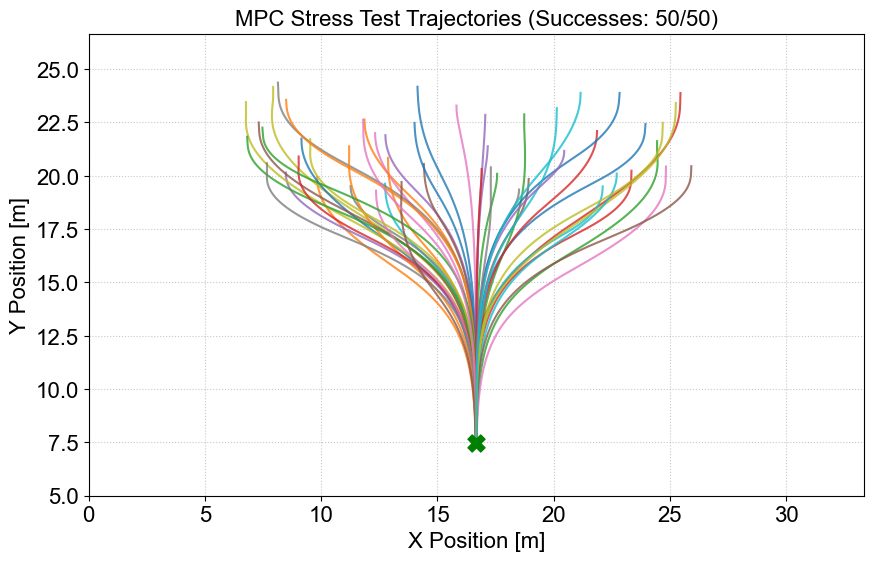

Successes: 50/50



In [ ]:
# Slide 4 - MPC Stress Test

stress_args = {
    "main_thruster_range": 0.55,
    "side_thruster_range": 0.55,
    "nozzle_angle_range": 0.55,
}

run_batch_tests_and_plot(submission_controller, 'MPC Stress Test Trajectories', stress_args, stress_scenarios, 'slide4_stress_test.png')